In [1]:
import mysql.connector
import pandas as pd
import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots

conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="0987654321",
    database="datamart_rappi"
)

query = """
SELECT 
    fp.tiempo_total_min,
    fp.minutos_retraso,
    fp.dist_asignacion_km,
    fp.tiempo_espera_rest_min,
    fp.cumple_sla,
    dt.hora_dia
FROM fact_pedidos fp
JOIN dim_tiempo dt ON fp.id_tiempo = dt.id_tiempo
LIMIT 5000
"""

df = pd.read_sql(query, conn)
conn.close()
print(f"Datos cargados: {df.shape[0]:,} registros")
print(df.columns.tolist())

Datos cargados: 5,000 registros
['tiempo_total_min', 'minutos_retraso', 'dist_asignacion_km', 'tiempo_espera_rest_min', 'cumple_sla', 'hora_dia']


C:\Users\Admin\AppData\Local\Temp\ipykernel_16296\2662459650.py:27: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


In [3]:
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="0987654321",
    database="datamart_rappi"
)

query = """
SELECT 
    fp.tiempo_total_min,
    fp.minutos_retraso,
    fp.dist_asignacion_km,
    fp.tiempo_espera_rest_min,
    fp.cumple_sla,
    dt.hora_dia
FROM fact_pedidos fp
JOIN dim_tiempo dt ON fp.id_tiempo = dt.id_tiempo
"""

df = pd.read_sql(query, conn)
conn.close()

print(f"Datos cargados: {df.shape[0]:,} registros")
print(df.columns.tolist())

Datos cargados: 10,000 registros
['tiempo_total_min', 'minutos_retraso', 'dist_asignacion_km', 'tiempo_espera_rest_min', 'cumple_sla', 'hora_dia']


C:\Users\Admin\AppData\Local\Temp\ipykernel_16296\28148312.py:20: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


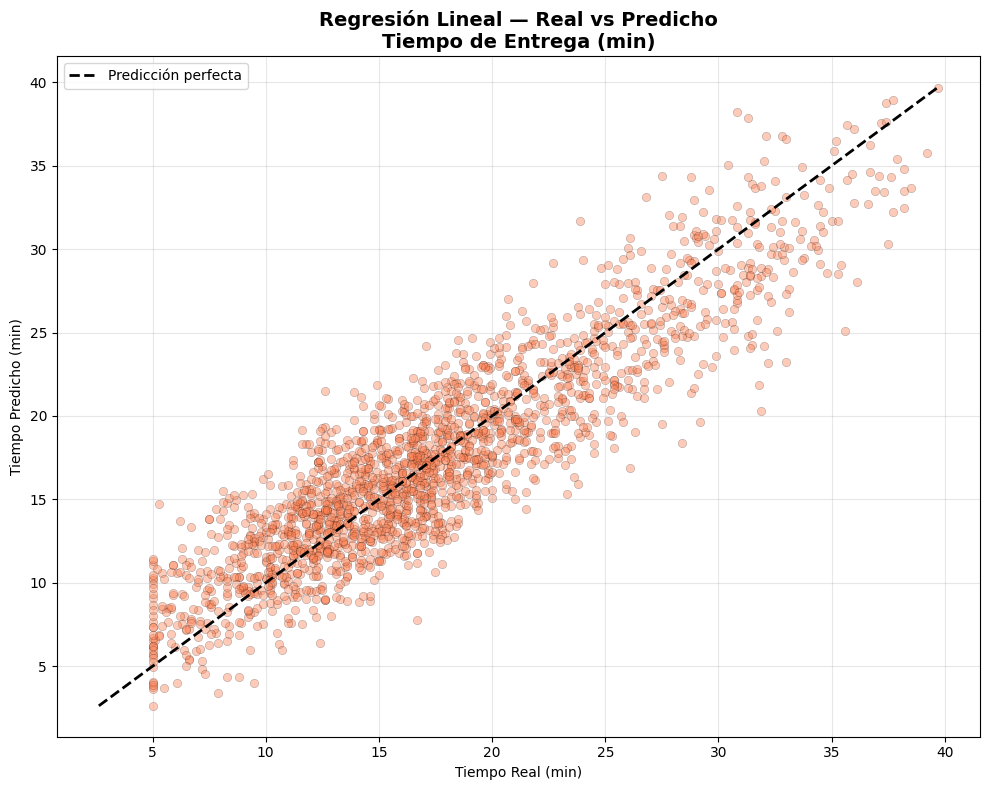

R²: 0.821
MAE: 2.40 min


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Variables predictoras y variable objetivo (sin hora_dia)
X = df[['dist_asignacion_km', 'tiempo_espera_rest_min']]
y = df['tiempo_total_min']

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Entrenar modelo
modelo = LinearRegression()
modelo.fit(X_train, y_train)

# Predecir
y_pred = modelo.predict(X_test)

# Gráfico
plt.figure(figsize=(10, 8))
plt.scatter(y_test, y_pred, alpha=0.4, color='coral', edgecolor='k', linewidth=0.3)

lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
plt.plot(lims, lims, '--', color='black', linewidth=2, label='Predicción perfecta')

plt.xlabel('Tiempo Real (min)')
plt.ylabel('Tiempo Predicho (min)')
plt.title('Regresión Lineal — Real vs Predicho\nTiempo de Entrega (min)', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

from sklearn.metrics import r2_score, mean_absolute_error
print(f"R²: {r2_score(y_test, y_pred):.3f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f} min")

In [8]:
print(df.columns.tolist())

['tiempo_total_min', 'minutos_retraso', 'dist_asignacion_km', 'tiempo_espera_rest_min', 'cumple_sla', 'hora_dia']


In [9]:
import os
for archivo in os.listdir():
    if 'tiempo' in archivo.lower():
        print(archivo)

In [10]:
df_gold = pd.read_csv('gold_fact_pedidos.csv')
print(df_gold.columns.tolist())

['id_pedido', 'id_tiempo', 'id_zona', 'id_restaurante', 'id_repartidor', 'id_cliente', 'id_estado', 'tiempo_total_min', 'dist_asignacion_km', 'dist_entrega_km', 'tiempo_espera_rest_min', 'cumple_sla', 'minutos_retraso', 'valor_pedido_soles']


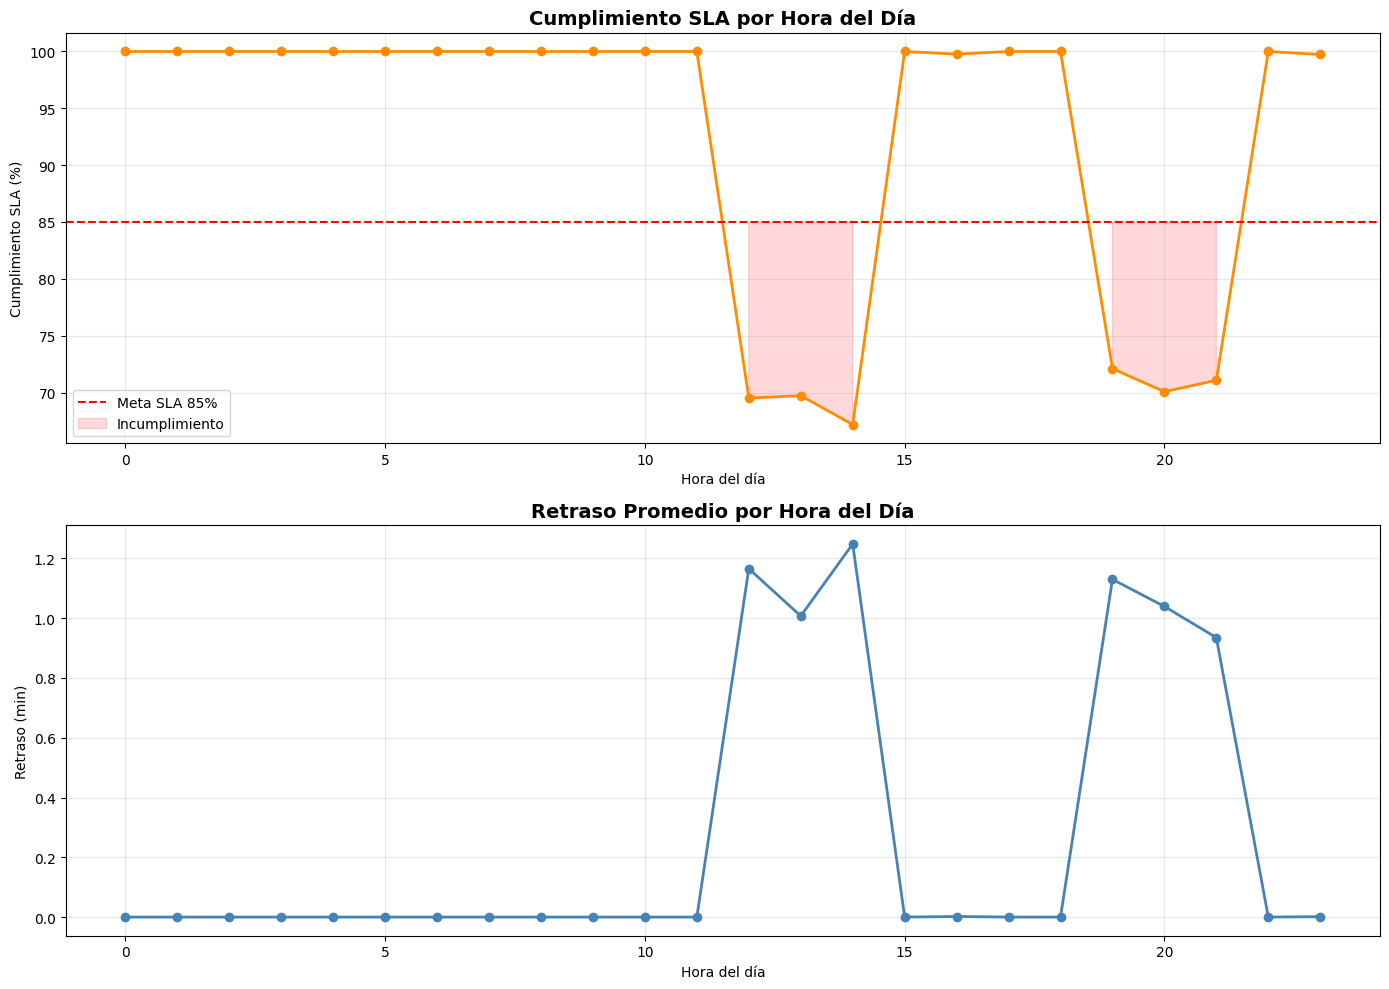

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Agrupar por hora
resumen_hora = df.groupby('hora_dia').agg(
    cumplimiento_sla=('cumple_sla', 'mean'),
    retraso_promedio=('minutos_retraso', 'mean')
).reset_index()

resumen_hora['cumplimiento_sla'] = resumen_hora['cumplimiento_sla'] * 100

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico 1: Cumplimiento SLA
ax1.plot(resumen_hora['hora_dia'], resumen_hora['cumplimiento_sla'], 
         marker='o', color='darkorange', linewidth=2)
ax1.axhline(y=85, color='red', linestyle='--', label='Meta SLA 85%')
ax1.fill_between(resumen_hora['hora_dia'], resumen_hora['cumplimiento_sla'], 85,
                  where=(resumen_hora['cumplimiento_sla'] < 85),
                  color='red', alpha=0.15, label='Incumplimiento')
ax1.set_title('Cumplimiento SLA por Hora del Día', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hora del día')
ax1.set_ylabel('Cumplimiento SLA (%)')
ax1.legend()
ax1.grid(alpha=0.3)

# Gráfico 2: Retraso promedio
ax2.plot(resumen_hora['hora_dia'], resumen_hora['retraso_promedio'], 
         marker='o', color='steelblue', linewidth=2)
ax2.set_title('Retraso Promedio por Hora del Día', fontsize=14, fontweight='bold')
ax2.set_xlabel('Hora del día')
ax2.set_ylabel('Retraso (min)')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

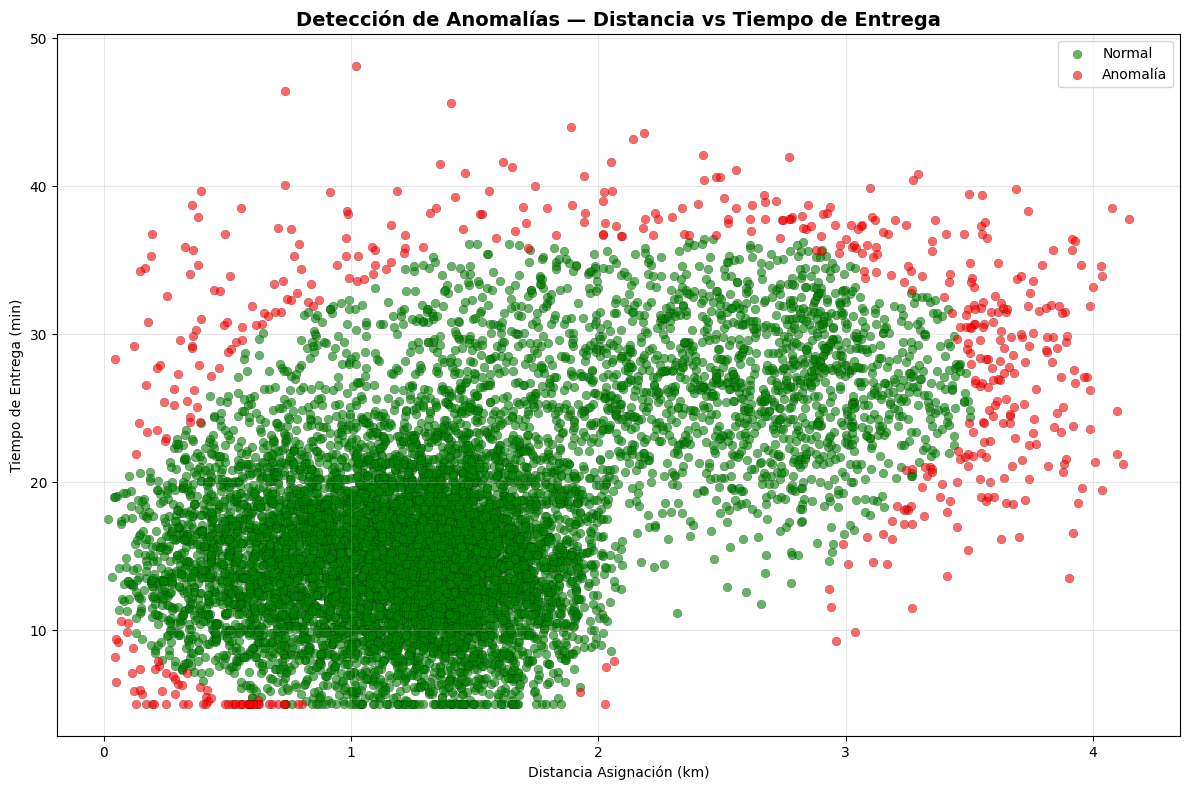

Total anomalías detectadas: 500 de 10000 pedidos


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

# Variables para detectar anomalías
X = df[['dist_asignacion_km', 'tiempo_total_min']]

# Modelo de detección de anomalías
modelo_anomalias = IsolationForest(contamination=0.05, random_state=42)
df['anomalia'] = modelo_anomalias.fit_predict(X)

# -1 = anomalía, 1 = normal
df['tipo'] = df['anomalia'].map({1: 'Normal', -1: 'Anomalía'})

# Gráfico
plt.figure(figsize=(12, 8))
colores = {'Normal': 'green', 'Anomalía': 'red'}

for tipo, color in colores.items():
    subset = df[df['tipo'] == tipo]
    plt.scatter(subset['dist_asignacion_km'], subset['tiempo_total_min'],
                c=color, label=tipo, alpha=0.6, edgecolor='k', linewidth=0.2, s=40)

plt.xlabel('Distancia Asignación (km)')
plt.ylabel('Tiempo de Entrega (min)')
plt.title('Detección de Anomalías — Distancia vs Tiempo de Entrega', fontsize=14, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Total anomalías detectadas: {(df['tipo']=='Anomalía').sum()} de {len(df)} pedidos")

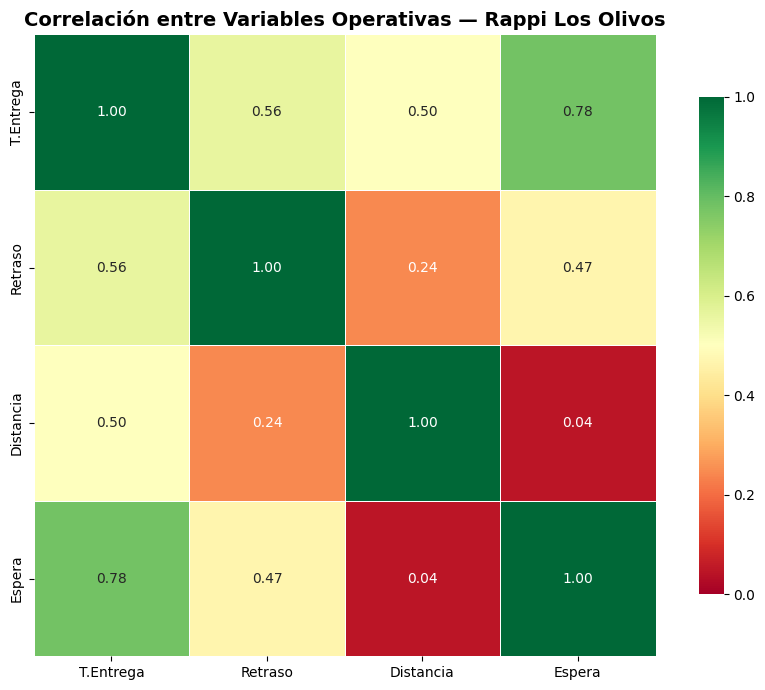

In [14]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Seleccionar y renombrar variables clave
df_corr = df[['tiempo_total_min', 'minutos_retraso', 'dist_asignacion_km', 'tiempo_espera_rest_min']].copy()
df_corr.columns = ['T.Entrega', 'Retraso', 'Distancia', 'Espera']

# Calcular correlación
matriz_corr = df_corr.corr()

# Gráfico
plt.figure(figsize=(9, 7))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='RdYlGn', 
            vmin=0, vmax=1, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})

plt.title('Correlación entre Variables Operativas — Rappi Los Olivos', 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
print("=" * 60)
print("FASE 1 — MODELO PREDICTIVO")
print("=" * 60)

print("""
JUSTIFICACIÓN DEL ENFOQUE PREDICTIVO:
Se usa un enfoque predictivo porque no basta con describir
lo que pasó (descriptivo), sino que necesitamos ANTICIPAR
si un pedido va a llegar tarde ANTES de asignarlo.

VARIABLE DEPENDIENTE (Y):
→ tiempo_total_min: Tiempo total de entrega en minutos

VARIABLES INDEPENDIENTES (X):
→ X1: dist_asignacion_km   — Distancia del repartidor al restaurante
→ X2: tiempo_espera_rest_min — Tiempo de espera en el restaurante  
→ X3: minutos_retraso       — Minutos de retraso acumulados
""")

# Verificar variables
X = df[["dist_asignacion_km", "tiempo_espera_rest_min", "minutos_retraso"]]
y = df["tiempo_total_min"]

print(f"Variable dependiente Y: {y.name}")
print(f"Variables independientes X: {list(X.columns)}")
print(f"Total registros: {len(df):,}")

FASE 1 — MODELO PREDICTIVO

JUSTIFICACIÓN DEL ENFOQUE PREDICTIVO:
Se usa un enfoque predictivo porque no basta con describir
lo que pasó (descriptivo), sino que necesitamos ANTICIPAR
si un pedido va a llegar tarde ANTES de asignarlo.

VARIABLE DEPENDIENTE (Y):
→ tiempo_total_min: Tiempo total de entrega en minutos

VARIABLES INDEPENDIENTES (X):
→ X1: dist_asignacion_km   — Distancia del repartidor al restaurante
→ X2: tiempo_espera_rest_min — Tiempo de espera en el restaurante  
→ X3: minutos_retraso       — Minutos de retraso acumulados

Variable dependiente Y: tiempo_total_min
Variables independientes X: ['dist_asignacion_km', 'tiempo_espera_rest_min', 'minutos_retraso']
Total registros: 10,000
